# Case Study: Analyzing Bumble Profiles

**As a data analyst working for Bumble, my task is to conduct a detailed exploratory analysis of user data to uncover insights into demographics, preferences, and behavioral trends.**

**My findings will help the product and marketing teams make data-driven decisions to enhance user engagement, optimize matchmaking algorithms, and personalize platform features, ultimately improving user satisfaction and platform growth.**

**The Goal is to 1. Clean the Data, 2. Process the Data, 3. Explore the data and 4.Visualise the Data.**

In [ ]:
# Installing required libraries.

import pandas as pd        # Pandas: used for data manipulation and analysis.
                           # Provides DataFrame and Series objects to handle tabular data efficiently.
                           # Commonly used for cleaning, transforming, and exploring datasets.

import numpy as np         # NumPy: fundamental package for numerical computing in Python.
                           # Provides support for arrays, mathematical functions, and linear algebra.
                           # Often used for handling numerical operations behind the scenes in Pandas.

import matplotlib.pyplot as plt  # Matplotlib: core plotting library in Python.
                                 # Used to create static, interactive, and publication-quality visualizations.
                                 # Helpful for line plots, bar charts, scatter plots, histograms, etc.

import seaborn as sns      # Seaborn: built on top of Matplotlib, specialized for statistical data visualization.
                           # Provides high-level functions to create attractive and informative plots easily.
                           # Great for heatmaps, pairplots, distribution plots, and correlation visualization.

from datetime import datetime  # datetime: built-in Python module for working with dates and times.
                               # Useful for parsing timestamps, calculating time differences, and formatting dates.
                               # Often required when datasets contain time-series data.

import warnings            # warnings: built-in Python module to manage warning messages.
                           # Helps suppress unnecessary warnings that clutter output.
                           # Commonly used in notebooks/projects to keep results clean.

warnings.filterwarnings('ignore')  # Ignores all warning messages.
                                   # Useful when you want a clean output without non-critical warnings.
                                   # Should be used carefully, as it may hide important alerts.

# Install gdown to download files from Google Drive
!pip install gdown
import gdown

# Download the file directly using its ID
file_id = '1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o'
output = 'bumble.csv'
gdown.download(id=file_id, output=output, quiet=False)

# Load into DataFrame
df = pd.read_csv(output)
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1HJFDNWNlkO2M5Gj3JHKt9VSI34QuW63o
To: /content/bumble.csv
100%|██████████| 13.7M/13.7M [00:00<00:00, 80.0MB/s]


   age     status gender       body_type               diet    drinks  \
0   22     single      m  a little extra  strictly anything  socially   
1   35     single      m         average       mostly other     often   
2   38  available      m            thin           anything  socially   
3   23     single      m            thin         vegetarian  socially   
4   29     single      m        athletic                NaN  socially   

                           education            ethnicity  height  income  \
0      working on college/university         asian, white    75.0      -1   
1              working on space camp                white    70.0   80000   
2     graduated from masters program                  NaN    68.0      -1   
3      working on college/university                white    71.0   20000   
4  graduated from college/university  asian, black, other    66.0      -1   

                           job       last_online  \
0               transportation  2012-06-28-20-

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB


#📍📌 Key Inferences about our dataset:
**1. Rows & Columns: 59946 & 17.**

**2. The dataset is predominantly categorical (14 object columns). There are only 3 numerical columns: age, height, and income.**

**3. Diet, Pets, and Religion have the most missing values (roughly 33–40% missing). This suggests these fields were likely optional for users.**

**4. Age, Status, Gender, Income, and Location are fully populated, likely because they were required fields during registration.**

**📌 Part 1: Data Cleaning**


# **Questions:**

**Q1.Which columns in the dataset have missing values, and what percentage of data is missing in each column?**



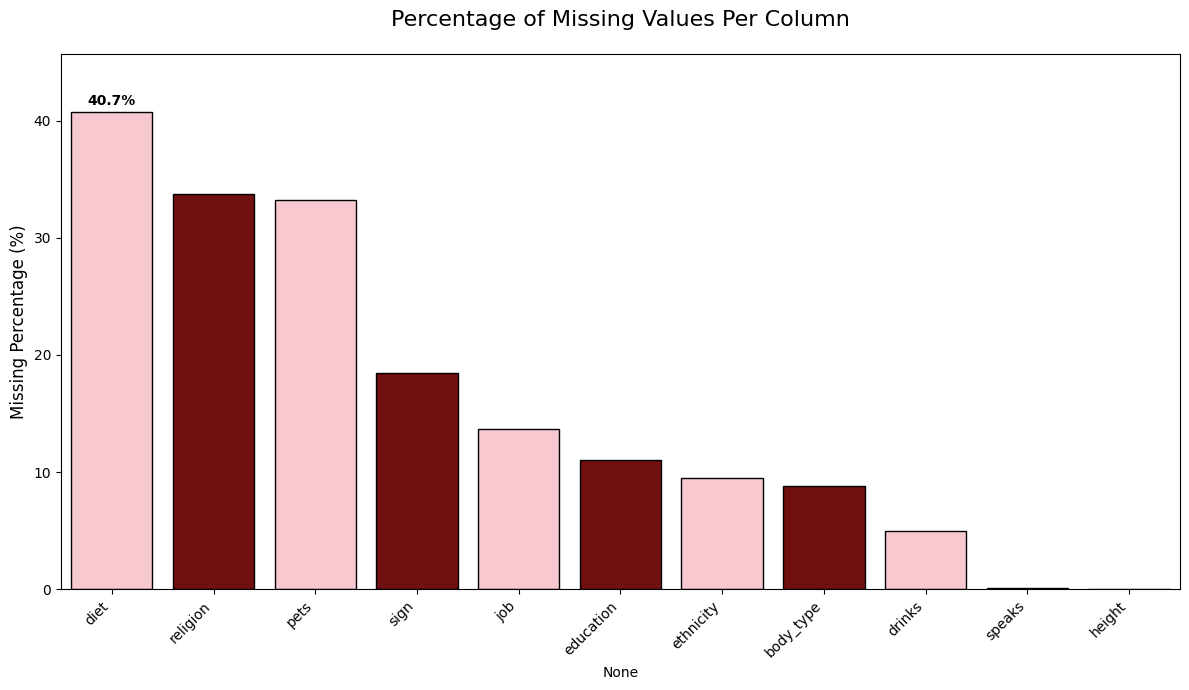

In [ ]:
#1.Calculate & Filter: Gets percentage of missing values only for columns that have them
missing_data = (df.isnull().mean() * 100).loc[lambda x: x > 0].sort_values(ascending=False)

#2. Setup colors: Create a list that alternates pink and maroon
colors = ['pink', 'maroon'] * (len(missing_data) // 2 + 1)

#3. Create the Plot
plt.figure(figsize=(12, 7))
ax = sns.barplot(
    x=missing_data.index,
    y=missing_data.values,
    palette=colors[:len(missing_data)], # Match the exact number of bars
    edgecolor='black'
)

#4. Add exact percentages on top
ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3, fontweight='bold')

#Formatting for clarity
plt.title('Percentage of Missing Values Per Column', fontsize=16, pad=20)
plt.ylabel('Missing Percentage (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.ylim(0, missing_data.max() + 5) # Add space for labels
plt.tight_layout()

plt.show()

**2.** **Are there columns where more than 50% of the data is missing? Drop those columns where missing values are >50%?**

**No**

**3.Missing numerical data (e.g., height, income) should be
handled by imputing the median value of height and
income for the corresponding category, such as gender, age
group, or location. This ensures that the imputed values are
contextually relevant and reduce potential biases in the
analysis.**

In [ ]:
# 1. Calculate medians per group (result is a small Series)
median_map = df.groupby("gender")["height"].median()

# 2. Fill missing values using the map
df["height"] = df["height"].fillna(df["gender"].map(median_map))

**📌2.Data Types**

**Q1. Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?**

**Answer: We have already seen while we ran df.info() that no inconsistencies in the data types across columns , except for last_online
which needed to be stored as datetime.**

**Q2. Which columns require conversion to numerical data types for proper analysis (e.g., income)?**

**Answer: There are no columns that require conversion to numerical data type.**

**Q3. Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?**

In [ ]:
df["last_online"] = pd.to_datetime(
    df["last_online"],
    format="%Y-%m-%d-%H-%M",
    cache=True
)

**Conversion into datetime format is done.**

**📌 3. Outliers**

**Q1.Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?**

In [ ]:
df.describe()

,age,height,income,last_online
count,59946.000000,59946.000000,59946.000000,59946
mean,32.340290,68.295282,20033.222534,2012-05-22 06:43:35.300770560
min,18.000000,1.000000,-1.000000,2011-06-27 01:52:00
25%,26.000000,66.000000,-1.000000,2012-05-29 20:37:15
50%,30.000000,68.000000,-1.000000,2012-06-27 14:30:00
75%,37.000000,71.000000,-1.000000,2012-06-30 01:09:00
max,110.000000,95.000000,1000000.000000,2012-07-01 08:57:00
std,9.452779,3.994738,97346.192104,NaN


**📌Observation:**
**Yes there are outliers in the numerical columns which are age, height and income.**


In [ ]:
# 1. Select only the columns you need and aggregate min/max in one go
ranges = df[['age', 'height', 'income']].agg(['min', 'max'])

# 2. Print the results using the aggregated data
for col in ranges.columns:
    print(f"The {col} range is : ({ranges.loc['min', col]}, {ranges.loc['max', col]})")

The age range is : (18, 110)
The height range is : (1.0, 95.0)
The income range is : (-1, 1000000)


**📌To identify outliers,used describe() to check if they fall below the 25th percentile or above the 75th percentile. Here we used max() and min() to calculate the range, which provides the maximum and minimum values of the data, respectively.**


**Q2.Any -1 values in numerical columns like income should be
replaced with 0, as they may represent missing or invalid
data.**


In [ ]:
# Select, replace, and print in one optimized chain
print(df[["income", "age", "height"]].replace(-1, 0))

       income  age  height
0           0   22    75.0
1       80000   35    70.0
2           0   38    68.0
3       20000   23    71.0
4           0   29    66.0
...       ...  ...     ...
59941       0   59    62.0
59942       0   24    72.0
59943  100000   42    71.0
59944       0   27    73.0
59945       0   39    68.0

[59946 rows x 3 columns]


**📌Here we Used replace() to replace the -1 values with 0 in these columns.**


**Q3. For other outliers, rather than deleting them, calculate the
mean and median values using only the middle 80% of the
data (removing extreme high and low values). This
approach ensures that outliers do not disproportionately
impact the analysis while retaining as much meaningful
data as possible.**


In [ ]:
column_names = ['age', 'height', 'income']

# 1. Calculate all quantiles at once for all target columns
quantiles = df[column_names].quantile([0.10, 0.90])

for col in column_names:
    q1 = quantiles.loc[0.10, col]
    q3 = quantiles.loc[0.90, col]

    # 2. Use .between() to create a boolean mask
    # inclusive='neither' ensures we use strict > and <
    mask = df[col].between(q1, q3, inclusive='neither')

    # 3. Apply mask and calculate stats directly on the Series
    filtered_series = df.loc[mask, col]

    mean_val = filtered_series.mean()
    median_val = filtered_series.median()

    print(f"{col}: filtered_median: {median_val}, filtered_mean: {mean_val}")

age: filtered_median: 30.0, filtered_mean: 31.357685563997663
height: filtered_median: 68.0, filtered_mean: 68.25442646465552
income: filtered_median: 20000.0, filtered_mean: 26109.89010989011


**📌Here we used quantile(0.10) and quantile(0.90) to find middele 80% values to find mean() and median().**

**📌4.Missing Data Visualization**


**Q1.Create a heatmap to visualize missing values across the
dataset. Which columns show consistent missing data
patterns?**

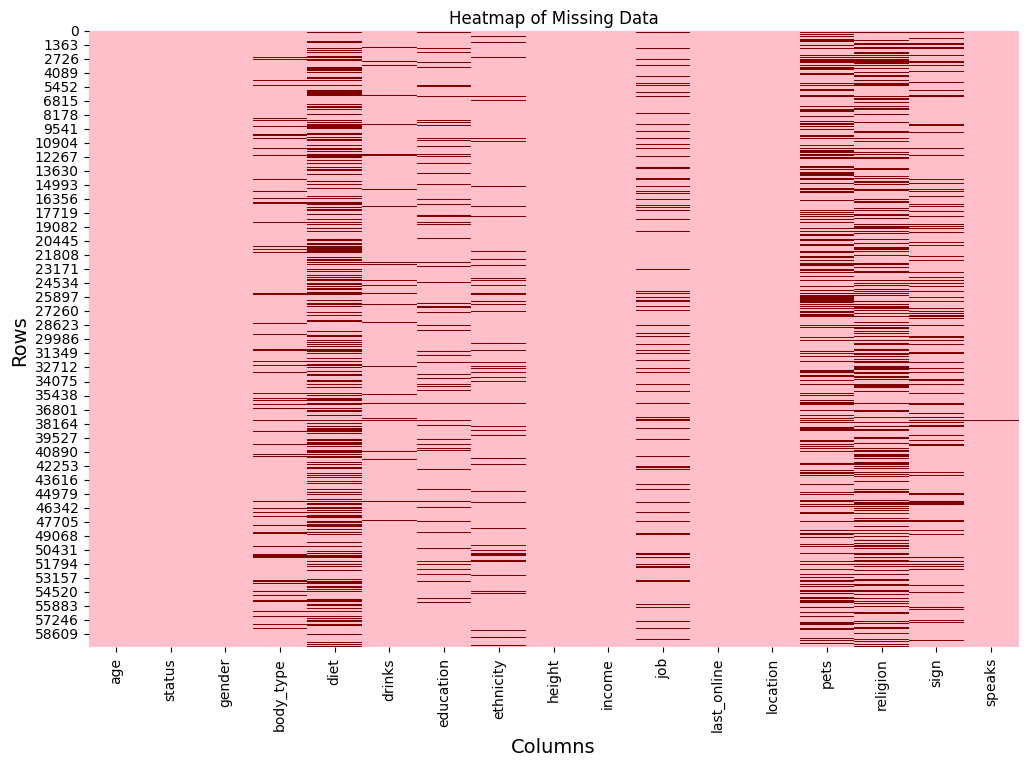

In [ ]:
from matplotlib.colors import LinearSegmentedColormap
# Create custom pink-maroon colormap
colors = ["pink", "maroon"]
cmap_custom = LinearSegmentedColormap.from_list("pink_maroon", colors)

plt.figure(figsize=(12, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=cmap_custom)
plt.title('Heatmap of Missing Data')
plt.xlabel('Columns', fontsize=14)
plt.ylabel('Rows', fontsize=14)
plt.show()

**Here we created the heatmap to visualize missing values across the dataset, We
used seaborn library for heatmap and used isnull function
The columns diet, religion and pets shows consistent missing data patterns.**


**📌Part 2: Data Processing**

**1. Binning and Grouping
Grouping continuous variables, such as age or income, into bins helps simplify analysis
and identify trends among specific groups. For instance, grouping users into age ranges
can reveal distinct patterns in behavior or preferences across demographics.**


**Here we specify the bins and label for age.**

**Then use cut() function, this pd.cut() function is used to categorize the age column
in the DataFrame into the defined bins.**


In [ ]:
bins = [18,25, 35, 45, 110]
label = ["18-25", "26-35", "36-45","46+"]
df["age_group"] = pd.cut(df["age"], bins, labels= label)
df["age_group"]

,age_group
0,18-25
1,26-35
2,36-45
3,18-25
4,26-35
...,...
59941,46+
59942,18-25
59943,36-45
59944,26-35


In [ ]:
df[['age','age_group']].head(10)

,age,age_group
0,22,18-25
1,35,26-35
2,38,36-45
3,23,18-25
4,29,26-35
5,29,26-35
6,32,26-35
7,31,26-35
8,24,18-25
9,37,36-45


**2. Group income into categories like "Low Income,"
"Medium Income," and "High Income" based on meaningful
thresholds (e.g., quartiles). What insights can be derived
from these groups?**

In [ ]:
# 1. Calculate quantiles in one go
quantiles = df["income"].quantile([0.10, 0.90])
q1, q3 = quantiles[0.10], quantiles[0.90]

# 2. Vectorized binning using pd.cut
# Bins: (-infinity to Q1], (Q1 to Q3], (Q3 to infinity]
df["income_category"] = pd.cut(
    df["income"],
    bins=[-np.inf, q1, q3, np.inf],
    labels=["Low Income", "Medium Income", "High Income"],
    include_lowest=True
)

# 3. Efficiently aggregate and rename
income_distribution_count_data = (
    df["income_category"]
    .value_counts()
    .reset_index(name="User Count")
    .rename(columns={"index": "Income Category"})
)

income_distribution_count_data

,income_category,User Count
0,Low Income,48442
1,Medium Income,5980
2,High Income,5524


**Here we grouped income into categories as Low Income, Medium Income and High Income using 25th, 50th and 90th percentile.**


**2.Derived Features**

**Q1.Create a new feature, profile_completeness, by calculating
the percentage of non-missing values for each user profile.
How complete are most user profiles, and how does
completeness vary across demographics?**


**Values in each user profile by using notnull().sum() divided by the total number of
columns with shape[], and multiplying by 100.
The average profile_completeness was analyzed across different demographics by
grouping the data by status.
The analysis revealed that the 'unknown' category had lower profile completeness compared to other status categories.**


In [ ]:
df["profile_completeness"] = df.notnull().sum(axis=1) / df.shape[1] * 100
print(df["profile_completeness"])
print(df.groupby("status")["profile_completeness"].mean())

0        100.000000
1        100.000000
2         84.210526
3         94.736842
4         89.473684
            ...    
59941     84.210526
59942    100.000000
59943     94.736842
59944    100.000000
59945     94.736842
Name: profile_completeness, Length: 59946, dtype: float64
status
available         91.364470
married           90.747029
seeing someone    91.115871
single            90.774803
unknown           84.210526
Name: profile_completeness, dtype: float64


**3. Unit Conversion
Standardizing units across datasets is essential for consistency, especially when working
with numerical data. In the context of the Bumble dataset, users’ heights are given in
inches, which may not be intuitive for all audiences.
Q1.Convert the height column from inches to centimeters using the conversion factor (1
inch = 2.54 cm). Store the converted values in a new column, height_cm.**

**Here we convert hight column from inches to centimeters
We are multiplying the df['height'] by 2.54to convert to centimeter.**

In [ ]:
df['height_cm'] = df['height'] *2.54
df['height_cm']
print(df[["height" , "height_cm"]])

       height  height_cm
0        75.0     190.50
1        70.0     177.80
2        68.0     172.72
3        71.0     180.34
4        66.0     167.64
...       ...        ...
59941    62.0     157.48
59942    72.0     182.88
59943    71.0     180.34
59944    73.0     185.42
59945    68.0     172.72

[59946 rows x 2 columns]


**📌 Part 3: Data Analysis**


**1. Demographic Analysis**


**Questions**

**Q1.What is the gender distribution (gender) across the platform? Are there any significant imbalances?**

In [ ]:
gender_count = df['gender'].value_counts()
print(f"Gender distribution (COUNT): \n{gender_count}")

Gender distribution (COUNT): 
gender
m    35829
f    24117
Name: count, dtype: int64


**📌Observation: We can see that the number of male users are higher than the number of female
users.**


**Q2. What are the proportions of users in different status
categories (e.g., single, married, seeing someone)? What
does this suggest about the platform’s target audience?**

**Here, we use the value_counts() function to count the number of users in each status category.**



In [ ]:
status_count = df['status'].value_counts()
print(f"Status distribution (COUNT): \n{status_count}")


Status distribution (COUNT): 
status
single            55697
seeing someone     2064
available          1865
married             310
unknown              10
Name: count, dtype: int64


In [ ]:
status_distribution_percent = df['status'].value_counts()*100/len(df['status'])
print(f"Status distribution (PERCENTAGE): \n{status_distribution_percent}")


Status distribution (PERCENTAGE): 
status
single            92.911954
seeing someone     3.443099
available          3.111133
married            0.517132
unknown            0.016682
Name: count, dtype: float64


**📌The output shows that 92% of users are single, which is much higher than expected.**

**Since most users are single, marketing campaigns should focus on this group and
highlight features for singles seeking meaningful connections, casual dating, or
long-term relationships.**

**Q3.How does status vary by gender? For example, what
proportion of men and women identify as single?**


In [ ]:
status_gender_distribution = df.groupby(["status", "gender"]).size() / len(df) * 100
status_gender_df = status_gender_distribution.reset_index(name="Percentage")
status_gender_df_sorted = status_gender_df.sort_values(by="Percentage", ascending=False)
print(status_gender_df_sorted)

           status gender  Percentage
7          single      m   55.680112
6          single      f   37.231842
1       available      m    2.016815
5  seeing someone      m    1.769926
4  seeing someone      f    1.673173
0       available      f    1.094318
3         married      m    0.291929
2         married      f    0.225203
9         unknown      m    0.010009
8         unknown      f    0.006673


**📌Observation:**

**Single Users: The majority of users (55.68% male, 37.23% female) are "single," indicating Bumble's focus on relationships and connections.**

**Available Users: A small percentage (2.02% male, 1.09% female) are "available," likely
open to casual interactions or new connections.**

**📌Recommendations**

**1.Focus on Singles: Marketing should target singles, emphasizing features for meaningful connections, casual dates, and long-term relationships.**

**2.Engage Available and Seeing Someone Users: Offer features for users open to casual dating or making new connections while in non-committed relationships.**

**📌2. Correlation Analysis**

**Q1.What are the correlations between numerical columns
such as age, income, gender Are there any strong positive
or negative relationships?**

In [ ]:
arr = df[['age','income','height']]
arr.corr()

,age,income,height
age,1.000000,-0.001004,-0.022253
income,-0.001004,1.000000,0.065048
height,-0.022253,0.065048,1.000000


**📌Analysis**

**Weak Correlation: Age, income, and height show little to no correlation.**

**Slight Positive Link: Income and height have a very weak positive correlation.**


**Q2.How does age correlate with income? Are older users
more likely to report higher income levels?**

In [ ]:
correlation = df["age"].corr(df["income"])
print(correlation)

-0.0010038398754361403


📌**The correlation between age and income was calculated using .corr(), resulting in a
very weak negative correlation of -0.00100.**

**📌3. Diet and Lifestyle Analysis: Lifestyle attributes such as diet, drinks provide insights into user habits and preferences.
Analyzing these factors helps identify compatibility trends and inform product features
like filters or match recommendations.**


**Q1.How do dietary preferences (diet) distribute across the
platform? For example, what percentage of users identify as
vegetarian, vegan, or follow "anything" diets?**

In [ ]:
diet_percentage = df['diet'].value_counts() * 100 / len(df['diet'])
diet_percentage

,count
diet,
mostly anything,27.666567
anything,10.314283
strictly anything,8.529343
mostly vegetarian,5.745171
mostly other,1.679845
strictly vegetarian,1.459647
vegetarian,1.112668
strictly other,0.754012
mostly vegan,0.563841


**The code calculates the percentage of each unique value in the 'diet' column using
value_counts() and divides by the total number of entries in the column.**

**📌Insights**

**27% of users follow a "mostly anything" diet, while 10% prefer anything.**

**Only 5% of users are mostly vegetarian.**

**Q2.How do drinking habits (drinks) vary across different diet
categories? Are users with stricter diets (e.g., vegan) less
likely to drink?**

**The code uses groupby("diet") to group the data by diet type and then applies .size()
to count the occurrences of "drinks" for each group.
It calculates the percentage of drinkers for each diet by dividing the count by the
total number of users (len(df)) and multiplying by 100.
The result is stored in a DataFrame using reset_index(), and the DataFrame is sorted
in descending order using sort_values(), then printed.**

In [ ]:
drink_percentage_by_diet = df.groupby("diet")["drinks"].size() / len(df) * 100
drinks_by_diet_df = drink_percentage_by_diet.reset_index(name="Drink Percentage")
sorted_drinks_df = drinks_by_diet_df.sort_values(by="Drink Percentage", ascending=False)
print(sorted_drinks_df)

                   diet  Drink Percentage
3       mostly anything         27.666567
0              anything         10.314283
10    strictly anything          8.529343
8     mostly vegetarian          5.745171
6          mostly other          1.679845
15  strictly vegetarian          1.459647
17           vegetarian          1.112668
13       strictly other          0.754012
7          mostly vegan          0.563841
9                 other          0.552164
14       strictly vegan          0.380342
16                vegan          0.226871
5         mostly kosher          0.143462
4          mostly halal          0.080072
11       strictly halal          0.030027
12      strictly kosher          0.030027
1                 halal          0.018350
2                kosher          0.018350


**📌Insights**

**Popular Diets: "Mostly anything" and "anything" have the highest drink percentages
(27.67% and 10.31%).**

**Low Drinkers: Strict diets like "strictly vegan" and "strictly halal" show very low drink
percentages.**

**Small Groups: Niche diets like "mostly kosher" and "strictly halal" have minimal drinkers.**

**📌4. Geographical Insights: Analyzing geographical data helps Bumble understand its user base distribution,
enabling targeted regional campaigns and feature localization. For instance, identifying
the top cities with active users can guide marketing efforts in those areas.**


**Q1.Extract city and state information from the location
column. What are the top 5 cities and states with the
highest number of users?**

In [ ]:
df[['city','state']] = df['location'].str.split(', ',expand = True, n=1)
df[['city','state']].head(5)

,city,state
0,south san francisco,california
1,oakland,california
2,san francisco,california
3,berkeley,california
4,san francisco,california


In [ ]:
top_cities = df["city"].value_counts(ascending = False).head(5)
top_states = df["state"].value_counts(ascending = False).head(5)
print(f"Top 5 cities with highest number of users\n {top_cities}" )
print(f"Top 5 states with highest number of users\n {top_states}")

Top 5 cities with highest number of users
 city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64
Top 5 states with highest number of users
 state
california       59855
new york            17
illinois             8
massachusetts        5
oregon               4
Name: count, dtype: int64


**📌Observation:**

**Top City: San Francisco has the highest number of users with 31,064, followed by Oakland and Berkeley, indicating a strong user presence in California's Bay Area.**

**State Distribution: California leads with 59,855 users, while other states like New
York, Illinois, and Texas have significantly fewer users, showing a concentration of
users in California.**

**Sparse Representation: States such as New York, Illinois, and Texas have very few
users, suggesting a potential opportunity for expanding Bumble's user base in these
areas.**

**Q2.How does age vary across the top cities? Are certain cities
dominated by younger or older users?**

In [ ]:
# Group by 'city' and calculate the average age
city_with_average_age = df.groupby('city')['age'].mean()

# Print cities with high average age (sorted in descending order)
print(f"Cities with high average age:\n{city_with_average_age.sort_values(ascending=False)}")

# Print cities with low average age (sorted in ascending order)
print(f"Cities with low average age:\n{city_with_average_age.sort_values(ascending=True)}")

Cities with high average age:
city
forest knolls      62.5
bellingham         59.0
port costa         53.0
seaside            50.0
redwood shores     47.0
                   ... 
san luis obispo    20.0
canyon             19.0
canyon country     19.0
isla vista         19.0
long beach         19.0
Name: age, Length: 198, dtype: float64
Cities with low average age:
city
canyon country    19.0
canyon            19.0
long beach        19.0
isla vista        19.0
fayetteville      20.0
                  ... 
redwood shores    47.0
seaside           50.0
port costa        53.0
bellingham        59.0
forest knolls     62.5
Name: age, Length: 198, dtype: float64


**📌Observation**

**Older Cities: Forest Knolls has the highest average age (62.5), followed by
Bellingham and Port Costa, indicating these cities have an older population.**

**Younger Cities: Fayetteville, Isla Vista, and Canyon have the lowest average ages
(around 19), suggesting a younger user base in these areas.**

**Age Gap: The data highlights a significant age gap between cities, with some areas
having a notably older demographic, while others are dominated by younger users.**

**Q3.What are the average income levels in the top states or
cities? Are there regional patterns in reported income?**

In [ ]:
# Get the top 5 states by occurrence
top_five_states = df["state"].value_counts().nlargest(5).index

# Filter the dataframe to include only rows where 'state' is in the top 5
filtered_states_data = df[df["state"].isin(top_five_states)]

# Calculate the average income for each of these top 5 states
average_income_by_state = (
    filtered_states_data.groupby("state")["income"]
    .mean()
    .sort_values(ascending=False)  # Sort from highest to lowest income
)

# Print the sorted average income by state
print(average_income_by_state)

state
new york         31763.823529
california       20043.465609
massachusetts     5999.200000
illinois            -1.000000
oregon              -1.000000
Name: income, dtype: float64


**📌Observation**

**Highest Income: New York has the highest average income (31,763) followed by California with 20,043, indicating a higher earning population in these states.**

**Lower Income: Massachusetts, Texas, and Illinois show lower average incomes, with
Illinois having a negative value, which might suggest missing or erroneous data.**

**📌5. Height Analysis
Physical attributes like height are often considered important in dating preferences.
Analyzing height patterns helps Bumble understand user demographics and preferences
better.**


**Q1.What is the average height of users across different
gender categories?**

In [ ]:
# 1. Convert 'gender' to a category (massive speedup for large data)
df["gender"] = df["gender"].astype("category")

# 2. Subset ONLY the required columns before grouping
# This reduces memory overhead significantly on wide dataframes
height_gender = df[["gender", "height"]].groupby("gender", observed=True)["height"].mean()

print(height_gender)

gender
f    65.103869
m    70.443468
Name: height, dtype: float64


**📌Observation**

**The result shows that male users have an average height of 70.44, while female users
have an average height of 65.10.**


**Q2.How does height vary by age_group? Are there noticeable
trends among younger vs. older users?**

In [ ]:
# 1. Convert to categorical to speed up the 'Split' phase
df["age_group"] = df["age_group"].astype("category")

# 2. Slice the dataframe to include only necessary columns
# 3. Calculate mean using observed=True to ignore empty categories
height_by_age = (
    df[["age_group", "height"]]
    .groupby("age_group", observed=True)["height"]
    .mean()
)

print(height_by_age)

age_group
18-25    68.224532
26-35    68.406764
36-45    68.325095
46+      67.941167
Name: height, dtype: float64



**📌Observation: **

**Consistent Heights: Users across all age groups have similar average heights,
ranging from 67.94 to 68.41 inches.**

**Slight Variation: The 26-35 age group has the highest average height (68.41), while
the 46+ group has the lowest (67.94).**


**Q3.What is the distribution of height within body_type
categories (e.g., athletic, curvy, thin)? Do the distributions
align with expectations?**

In [ ]:
height_body_type = df.groupby("body_type")["height"].mean().sort_values(ascending=False)
print(height_body_type)

body_type
athletic          69.707336
jacked            69.292162
used up           69.180282
overweight        68.948198
a little extra    68.820084
fit               68.546062
skinny            68.544176
average           68.100805
thin              67.866058
rather not say    67.272727
full figured      66.464817
curvy             65.210245
Name: height, dtype: float64


**📌Observation**
**Taller Body Types: "Athletic" users have the highest average height (69.71), followed
by "Jacked" and "Used Up" body types.
Shorter Body Types: "Curvy" and "Full Figured" have the lowest average heights
(65.21 and 66.46), with "Rather Not Say" also being shorter (67.27).**


**📌6. Income Analysis: Income is often an important factor for users on dating platforms. Understanding its
distribution and relationship with other variables helps refine features like user search
filters or personalized recommendations.**

**Q1.What is the distribution of income across the platform?
Are there specific income brackets that dominate? (don't
count 0)**


In [ ]:
# Use .loc to filter rows and select the 'income' column simultaneously
# This skips creating an intermediate DataFrame object
income_distribution = (
    df.loc[df["income"] > 0, "income"]
    .describe()
    .round(2)
)

print(income_distribution)

count      11504.00
mean      104394.99
std       201433.53
min        20000.00
25%        20000.00
50%        50000.00
75%       100000.00
max      1000000.00
Name: income, dtype: float64


**📌Observation:**
**The dominating income category is 20000 with the number of users as 2952.**


**Q2.How does income vary by age_group and gender? Are
older users more likely to report higher incomes?**

**We are grouping the data by the 'age group' column and calculating the mean income
for each group using .groupby().**

In [ ]:
# Define bins and labels for income brackets
income_bins = [0, 25000, 50000, 75000, 100000, float('inf')]
income_labels = ['<25K', '25K-50K', '50K-75K', '75K-100K', '100K+']

# Filter out zero income and create income brackets
data_nonzero_income = df[df['income'] > 0].copy()
data_nonzero_income['income_bracket'] = pd.cut(data_nonzero_income['income'], bins=income_bins, labels=income_labels)

# Get the count of users in each income bracket
income_distribution = data_nonzero_income['income_bracket'].value_counts().sort_index()

# Print the income distribution
print(income_distribution)

income_bracket
<25K        2952
25K-50K     3028
50K-75K     1443
75K-100K    2732
100K+       1349
Name: count, dtype: int64


In [ ]:
# Group by age group and gender and calculate the mean income
income_by_age_gender = df.groupby(['age_group', 'gender'], observed=True)['income'].mean()

# Pivot the table to have separate columns for male and female income
income_by_age_gender_pivot = income_by_age_gender.unstack(level='gender')

# Display the result, rounded to 2 decimal places
print(income_by_age_gender_pivot.round(2))

gender            f         m
age_group                    
18-25      12403.12  26231.87
26-35      10535.01  25394.00
36-45      11318.38  27786.40
46+        11082.80  25696.32


**📌Observation:**

**Older users do not necessarily report higher incomes. In fact, the 26-35 age group
has the highest average income, suggesting that income tends to peak in the late
20s and early 30s, when individuals are more established in their careers.**

In [ ]:
# Group by age_group and calculate the mean income, excluding incomes that are not positive.
average_income_by_age = df[df['income'] > 0].groupby('age_group')['income'].mean()

# Print the result
print(f"Income Distribution Across Age Groups:\n\n{average_income_by_age}")

Income Distribution Across Age Groups:

age_group
18-25    101760.808926
26-35    108869.783617
36-45    105937.645416
46+       91844.426624
Name: income, dtype: float64


**📌Part 4: Data Visualization**


**📌1. Age Distribution: Understanding the distribution of user ages can reveal whether the platform caters to specific demographics or age groups. This insight is essential for targeted marketing and user experience design.**

**Q1.Plot a histogram of age with a vertical line indicating the
mean age. What does the distribution reveal about the
most common age group on the platform?**


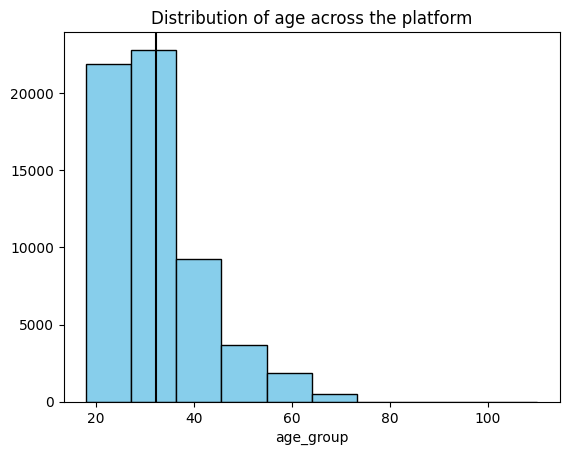

In [ ]:
plt.hist(df["age"], color = "skyblue", edgecolor= "black")
mean_age = df["age"].mean()
plt.axvline(mean_age, color= "black", label= "mean age")
plt.xlabel("age_group")
plt.title("Distribution of age across the platform")
plt.show()

**📌We used a histogram to visualize the distribution of the most common age group.
By calculating the mean age and representing it with a vertical line using axvline, the
result shows that users in their 30s are the most prevalent age group on the
platform.**

**Q2.How does the age distribution differ by gender? Are there
age groups where one gender is more prevalent?**

Text(0.5, 1.0, 'Age distribution differ by gender')

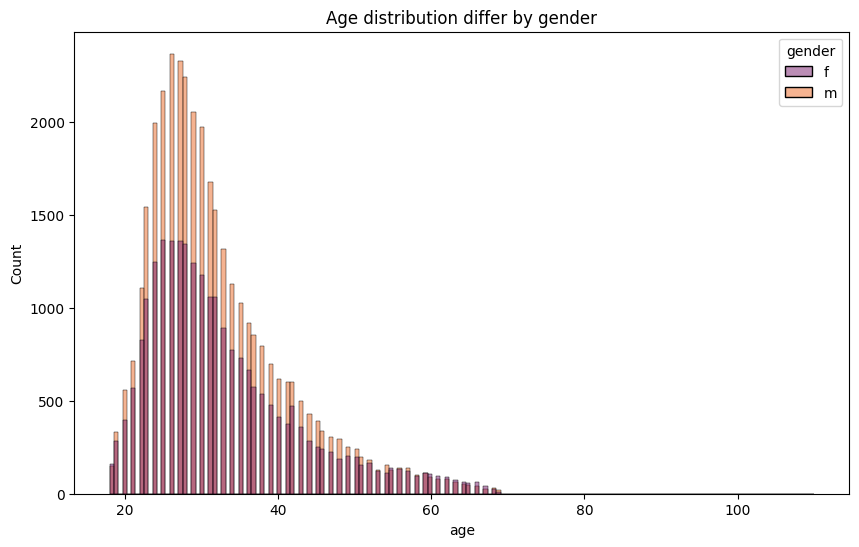

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="age", hue="gender", palette = "inferno")
plt.title("Age distribution differ by gender")


**📌2. Income and Age: Visualizing the relationship between income and age helps uncover patterns in reported income levels across age groups, which could inform user segmentation strategies.**

**Q1.Use a scatterplot to visualize the relationship between
income and age, with a trend line indicating overall
patterns. Are older users more likely to report higher
incomes?**

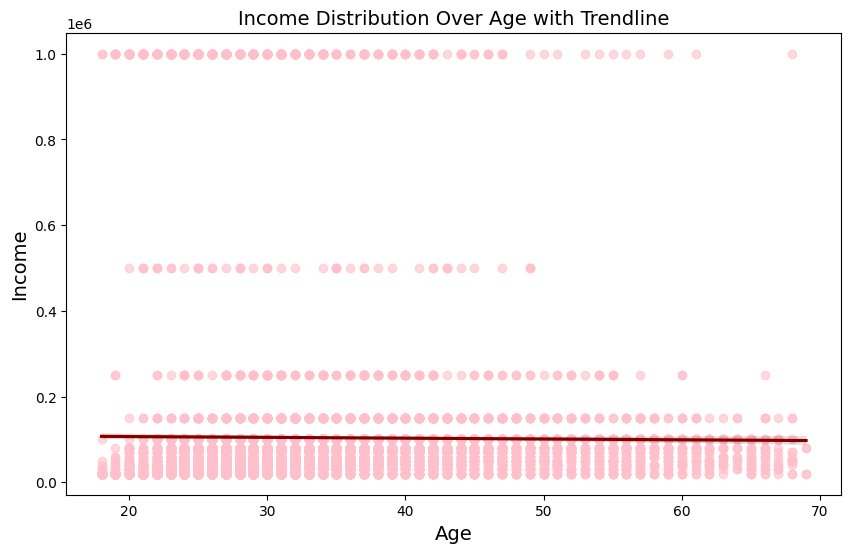

In [ ]:
# 1. Filter rows AND select only necessary columns in one step
# This prevents the plotting engine from processing the entire dataframe
plot_data = df.loc[df['income'] > 0, ['age', 'income']]

# 2. Use subplots to define size (cleaner than plt.figure)
fig, ax = plt.subplots(figsize=(10, 6))

# 3. Efficiently create the regplot with requested colors
sns.regplot(
    data=plot_data,
    x='age',
    y='income',
    ax=ax,
    scatter_kws={'color': 'pink', 'alpha': 0.6}, # Pink points
    line_kws={'color': 'maroon'}                # Maroon trendline
)

# 4. Set properties directly on the Axes object
ax.set_title('Income Distribution Over Age with Trendline', fontsize=14)
ax.set_xlabel('Age', fontsize=14)
ax.set_ylabel('Income', fontsize=14)

# 5. Save the result instead of showing
plt.savefig('income_trend.png', bbox_inches='tight')

**The result indicates that most users, regardless of age,
have similar income levels, with income not showing a clear increase as age
progresses.**


**Q2.Create boxplots of income grouped by age_group. Which
age group reports the highest median income?**

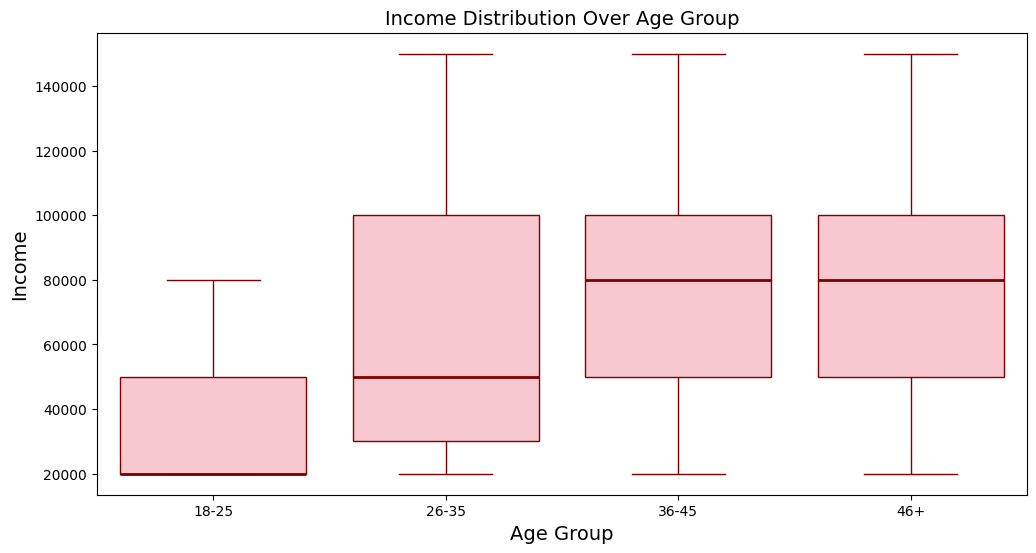

In [ ]:
# 1. Efficient filtering: Select only 'age_group' and 'income'
# This avoids loading unused columns into the plotting memory
plot_df = df.loc[df['income'] > 0, ['age_group', 'income']].copy()

# 2. Ensure age_group is categorical for faster processing and correct sorting
plot_df['age_group'] = plot_df['age_group'].astype('category')

# 3. Object-Oriented plotting with the requested Pink and Maroon theme
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=plot_df,
    x="age_group",
    y='income',
    showfliers=False,
    ax=ax,
    color="pink",           # Main box color
    boxprops={'edgecolor': 'maroon'},  # Box border
    whiskerprops={'color': 'maroon'},  # Whisker lines
    capprops={'color': 'maroon'},      # Whisker caps
    medianprops={'color': 'maroon', 'linewidth': 2} # Median line
)

# 4. Clean labels
ax.set_title('Income Distribution Over Age Group', fontsize=14)
ax.set_xlabel('Age Group', fontsize=14)
ax.set_ylabel('Income', fontsize=14)

plt.show()

**Boxplots of income grouped by age group were created using sns.boxplot(). The
results show that the median income for the 36-45 and 46+ age groups is almost
identical.**

**Q3.Analyze income levels within gender and status
categories. For example, are single men more likely to
report higher incomes than single women?**

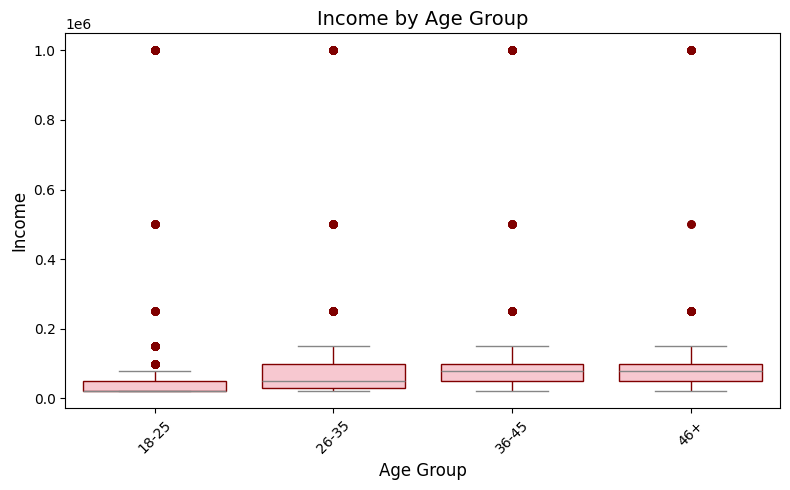

In [ ]:
# 1. Faster Filtering: Use .loc to filter and select only necessary columns at once
# 'income > 0' implicitly handles .notna() because NaN > 0 is False
plot_data = df.loc[df['income'] > 0, ['age_group', 'income']].copy()

# 2. Efficient Category handling
plot_data['age_group'] = plot_data['age_group'].astype('category')

# 3. Object-Oriented plotting (faster than plt.figure/plt.title)
fig, ax = plt.subplots(figsize=(8, 5))

sns.boxplot(
    data=plot_data,
    x='age_group',
    y='income',
    ax=ax,
    color='pink',                          # Main fill color
    boxprops={'edgecolor': 'maroon'},     # Box borders
    whiskerprops={'color': 'maroon'},     # Whisker lines
    flierprops={                           # Outlier styling
        'marker': 'o',
        'markerfacecolor': 'maroon',
        'markeredgecolor': 'maroon',
        'markersize': 5
    }
)

# 4. Direct label manipulation
ax.set_title('Income by Age Group', fontsize=14)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Income', fontsize=12)

# 5. Fast rotation
ax.tick_params(axis='x', rotation=45)

plt.tight_layout() # Ensures labels don't get cut off
plt.show()

**📌3. Pets and Preferences: Pets are often a key lifestyle preference and compatibility factor. Analyzing how pets
preferences distribute across demographics can provide insights for filters or
recommendations.**


**Q1.Create a bar chart showing the distribution of pets
categories (e.g., likes dogs, likes cats). Which preferences
are most common?**

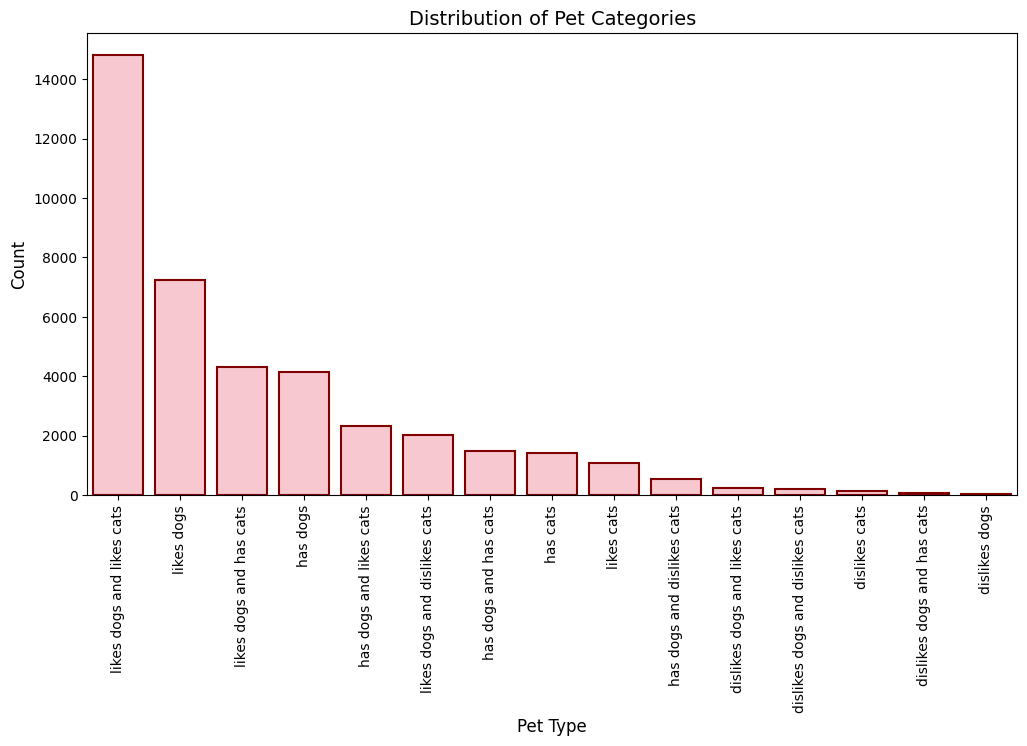

In [ ]:
# 1. Pre-calculate counts (much faster than letting Seaborn do it)
# We select only the 'pets' column to save memory
pet_counts = df['pets'].value_counts().reset_index()
pet_counts.columns = ['pets', 'count']

# 2. Use the Object-Oriented interface for better performance
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Use barplot with pre-calculated data and your Pink/Maroon theme
sns.barplot(
    data=pet_counts,
    x="pets",
    y="count",
    ax=ax,
    color="pink",
    edgecolor="maroon",
    linewidth=1.5
)

# 4. Optimized labeling and rotation
ax.set_title("Distribution of Pet Categories", fontsize=14)
ax.set_xlabel("Pet Type", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.tick_params(axis='x', rotation=90)

plt.show()

The distribution of pet preferences was visualized using sns.countplot(). The results
indicate that the "likes dogs and cats" category has the highest number of users,
while the "dislikes dogs" category has very few users.



**Q2.How do pets preferences vary across gender and
age_group? Are younger users more likely to report liking
pets compared to older users?**

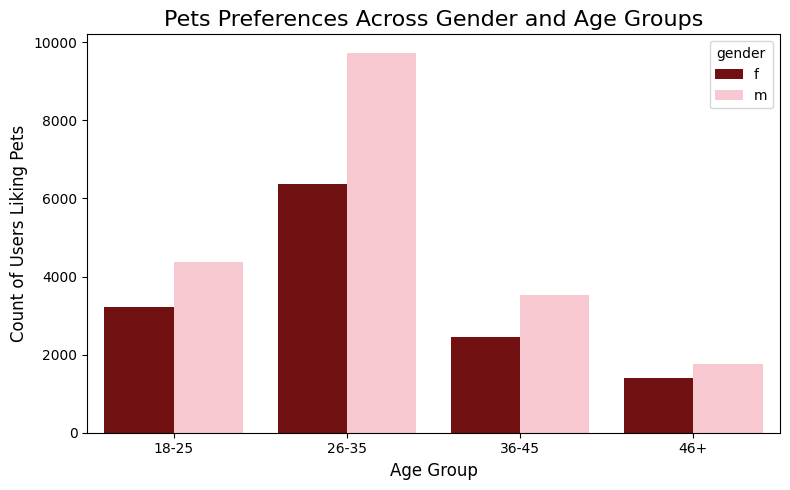

In [ ]:
# 1. Vectorized filtering and boolean logic
# .str.contains is much faster than .apply(lambda)
# 'na=False' handles NaN values automatically within the check
mask = (df['pets'].str.contains('likes', case=False, na=False)) & \
       (df['pets'] != 'Not Specified')

# 2. Extract and group in one efficient step
# We select only the columns needed for the grouping to save memory
age_gender_pets = (
    df.loc[mask, ['age_group', 'gender']]
    .groupby(['age_group', 'gender'], observed=True)
    .size()
    .reset_index(name='count')
)

# 3. Object-Oriented Plotting
fig, ax = plt.subplots(figsize=(8, 5))

# Using your Pink and Maroon theme for consistency
sns.barplot(
    data=age_gender_pets,
    x='age_group',
    y='count',
    hue='gender',
    ax=ax,
    palette=['maroon', 'pink'] # High contrast for the hue categories
)

# 4. Direct label styling
ax.set_title('Pets Preferences Across Gender and Age Groups', fontsize=16)
ax.set_xlabel('Age Group', fontsize=12)
ax.set_ylabel('Count of Users Liking Pets', fontsize=12)

plt.tight_layout()
plt.show()

**📌4. Signs and Personality: Users’ self-reported zodiac signs (sign) can offer insights into personality preferences or
trends. While not scientifically grounded, analyzing this data helps explore fun and
engaging patterns.**

**Q1.Create a pie chart showing the distribution of zodiac signs
(sign) across the platform. Which signs are most and least
represented? Is this the right chart? If not, replace with right
chart.**


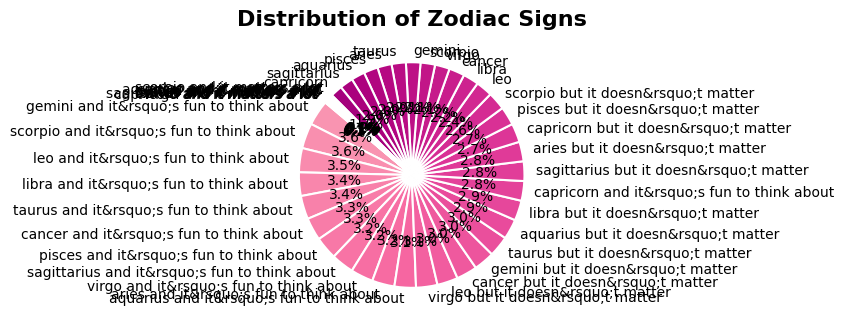

In [ ]:
# 1. Efficient aggregation
# value_counts() is highly optimized, but we store it as a dedicated Series
zodiac_counts = df["sign"].value_counts()

# 2. Use subplots for better control
fig, ax = plt.subplots(figsize=(8, 8))

# 3. Create a professional Pie Chart
# We use a color map (Colormap) to vary the pink/maroon tones
colors = plt.cm.get_cmap('RdPu')(np.linspace(0.4, 0.9, len(zodiac_counts)))

zodiac_counts.plot(
    kind='pie',
    ax=ax,
    autopct='%1.1f%%',       # Adds percentage labels automatically
    startangle=140,          # Rotates for better visual balance
    colors=colors,           # Applied the Pink/Maroon gradient
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    label=""                 # Removes the redundant "sign" label on the side
)

# 4. Clean up labels
ax.set_title("Distribution of Zodiac Signs", fontsize=16, fontweight='bold')

plt.tight_layout()
plt.show()

**A pie chart was used to visualize the distribution of zodiac signs across the platform.
However, the chart does not provide clear insights, making it an unsuitable choice
for this representation.**

**Q2.How does sign vary across gender and status? Are there
noticeable patterns or imbalances?**

**📌The Outputs below reveals a high degree of uniformity across all 12 zodiac signs, with no single sign showing a unique propensity for a specific relationship status or gender.**

**A significant imbalance is observed in relationship status, where 'Single' users dominate every sign—a reflection of the platform's demographic rather than astrological influence.**

**Furthermore, while male users outnumber female users across the board, the qualitative data suggests that women engage more descriptively with their signs, whereas the majority of all users view astrology with a casual or indifferent attitude.**

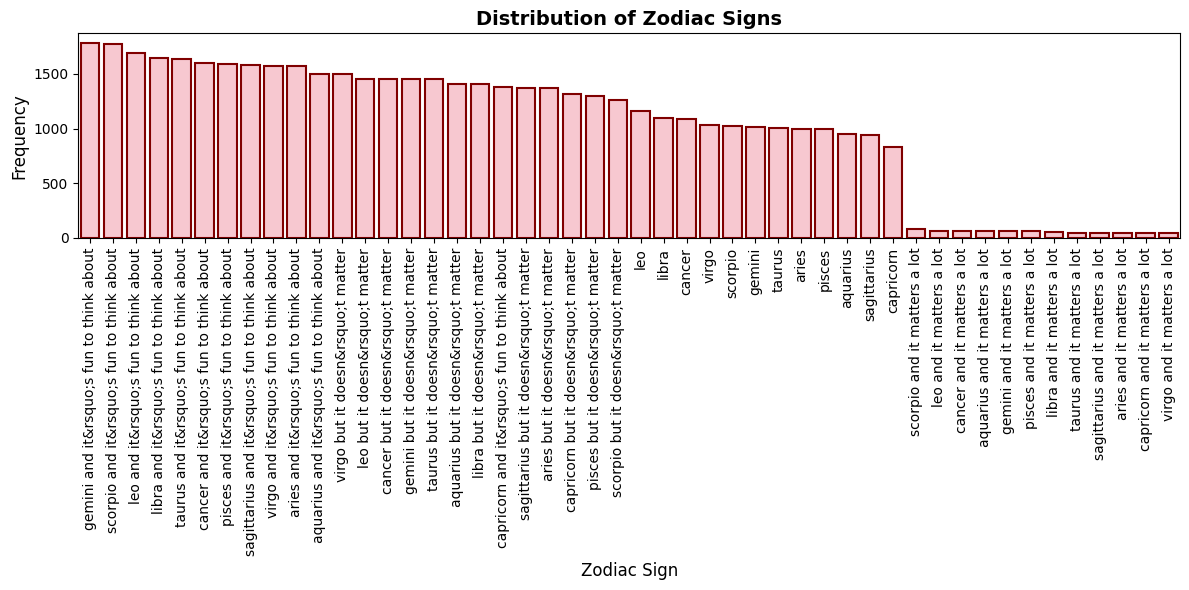

In [ ]:
# 1. Pre-calculate counts (faster than internal Seaborn aggregation)
# Sorting by index or value here is much more efficient
sign_counts = df["sign"].value_counts().reset_index()
sign_counts.columns = ['sign', 'count']

# 2. Object-Oriented interface for speed
fig, ax = plt.subplots(figsize=(12, 6))

# 3. Use barplot with the requested Pink/Maroon palette
sns.barplot(
    data=sign_counts,
    x="sign",
    y="count",
    ax=ax,
    color="pink",
    edgecolor="maroon",
    linewidth=1.5
)

# 4. Optimized labeling
ax.set_title("Distribution of Zodiac Signs", fontsize=14, fontweight='bold')
ax.set_xlabel("Zodiac Sign", fontsize=12)
ax.set_ylabel("Frequency", fontsize=12)

# 5. Faster tick rotation using the axis object
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

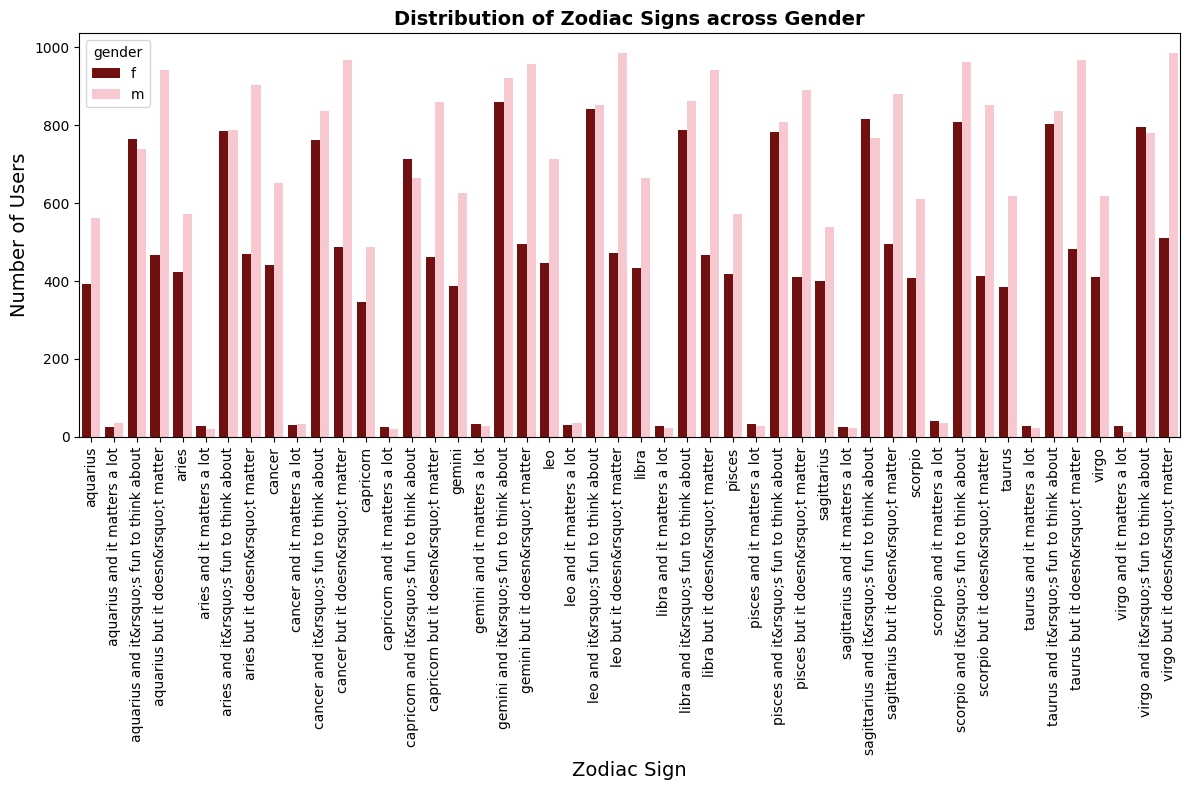

In [ ]:
# 1. Faster Grouping: Use categorical types and subsetting
# This reduces the computational load by treating strings as integers internally
plot_df = df[['sign', 'gender']].copy()
plot_df['sign'] = plot_df['sign'].astype('category')
plot_df['gender'] = plot_df['gender'].astype('category')

# 2. Efficient aggregation using observed=True
sign_across_gender = (
    plot_df.groupby(['sign', 'gender'], observed=True)
    .size()
    .reset_index(name='count')
)

# 3. Object-Oriented plotting interface (faster and more precise)
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Applying the Pink and Maroon palette
sns.barplot(
    data=sign_across_gender,
    x='sign',
    y='count',
    hue='gender',
    ax=ax,
    palette=['maroon', 'pink'] # High contrast for better visibility
)

# 5. Direct Axis manipulation for labels and title
ax.set_title('Distribution of Zodiac Signs across Gender', fontsize=14, fontweight='bold')
ax.set_xlabel('Zodiac Sign', fontsize=14)
ax.set_ylabel('Number of Users', fontsize=14)

# 6. Optimized tick rotation via the Axis object
ax.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

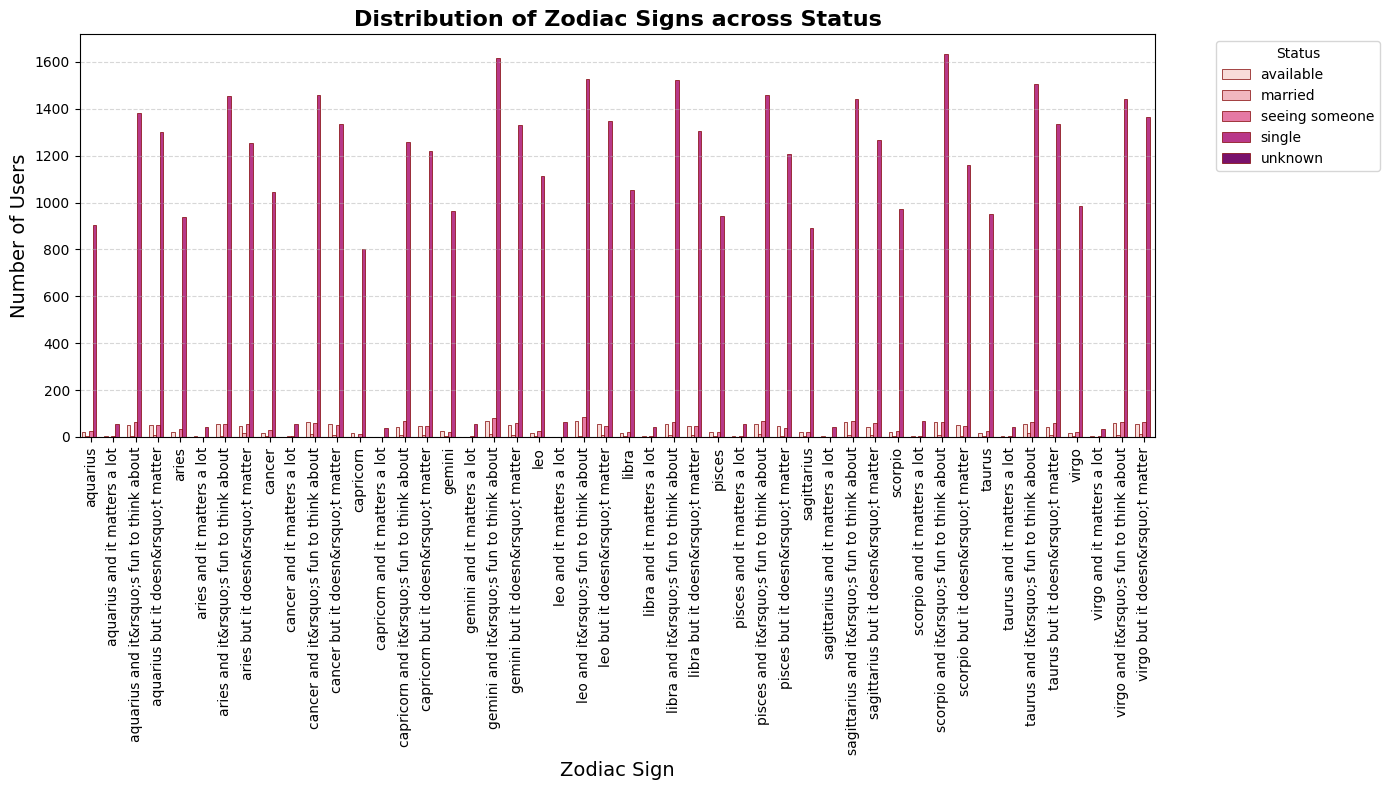

In [ ]:
# 1. Faster Grouping: Subset first and convert to categories
# This makes the "Split-Apply-Combine" process significantly faster
plot_df = df[['sign', 'status']].copy()
plot_df['sign'] = plot_df['sign'].astype('category')
plot_df['status'] = plot_df['status'].astype('category')

# 2. Efficient aggregation
sign_across_status = (
    plot_df.groupby(['sign', 'status'], observed=True)
    .size()
    .reset_index(name='count')
)

# 3. Object-Oriented plotting for better performance
fig, ax = plt.subplots(figsize=(14, 8))

# 4. Applying a Pink/Maroon gradient palette
# This handles multiple 'status' categories gracefully
status_colors = sns.color_palette("RdPu", n_colors=plot_df['status'].nunique())

sns.barplot(
    data=sign_across_status,
    x='sign',
    y='count',
    hue='status',
    ax=ax,
    palette=status_colors,
    edgecolor='maroon',
    linewidth=0.5
)

# 5. Direct Axis styling
ax.set_title('Distribution of Zodiac Signs across Status', fontsize=16, fontweight='bold')
ax.set_xlabel('Zodiac Sign', fontsize=14)
ax.set_ylabel('Number of Users', fontsize=14)

# 6. Optimized rotation and grid
ax.tick_params(axis='x', rotation=90)
ax.yaxis.grid(True, linestyle='dashed', alpha=0.5)

# Ensure the legend doesn't block the bars
ax.legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()